In [4]:
import pandas as pd
import sqlite3

In [5]:
df_2009 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')
df_comb = pd.concat([df_2009,df_2010], ignore_index=True)

In [6]:
df_comb.info()


<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [7]:
#we could assume that the missing value of "Customer ID" stands for non regitred 
# clients let's name it non_registred
#we have some missing Description we could try to copy the description of the same 
#StockCode if needed if it is new we could just keep it 
x = df_comb.isna().sum() / len(df_comb) * 100
print(x)

Invoice         0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.766873
Country         0.000000
dtype: float64


In [8]:
int((df_comb["Quantity"] < 0).sum())

22950

In [9]:
df_comb["Customer ID"] = df_comb["Customer ID"].fillna(0).astype(int)
df_comb["revenue"] = df_comb["Quantity"] * df_comb["Price"]
df_comb.columns = df_comb.columns.str.lower().str.replace(" ", "_")

In [10]:
# -----------------------------
# Flags — compute ALL of them before slicing any table out of df_comb
# -----------------------------
df_comb["is_return"] = df_comb["quantity"] < 0
df_comb["is_guest"] = df_comb["customer_id"] == 0

# Codes that look like real catalog product codes (5 digits + optional letter)
is_product_code = df_comb["stockcode"].astype(str).str.match(r"^\d{5}[A-Za-z]?$")

# Descriptions indicating a write-off / non-sale transaction
writeoff_keywords = (
    r"damag|given away|thrown away|adjust|sample|"
    r"broken|faulty|wrong code|missing|smashed"
)
is_writeoff_description = df_comb["description"].str.contains(
    writeoff_keywords, case=False, na=False
)

# Real product, but the transaction itself is a write-off (price 0, damage/giveaway/etc.)
df_comb["is_writeoff"] = is_product_code & is_writeoff_description & (df_comb["price"] == 0)

# Non-product / bookkeeping codes (POST, DOT, BANK CHARGES, gift_xxxx, etc.)
df_comb["is_non_product"] = ~is_product_code

# -----------------------------
# transactions — sliced LAST, after every flag exists
# -----------------------------
transactions = df_comb[
    [
        "invoice",
        "stockcode",
        "customer_id",
        "country",
        "invoicedate",
        "quantity",
        "price",
        "revenue",
        "is_return",
        "is_guest",
        "is_writeoff",
        "is_non_product",
    ]
].copy()

# -----------------------------
# customers — real, identifiable customers only (guests are not one person)
# -----------------------------
customers = (
    df_comb[df_comb["customer_id"] != 0]
    .groupby("customer_id")
    .agg(
        country=("country", lambda x: x.dropna().mode().iloc[0] if x.notna().any() else None),
        first_seen=("invoicedate", "min"),
        last_seen=("invoicedate", "max"),
    )
    .reset_index()
)

# -----------------------------
# guest activity by country — kept as its own table instead of discarded
# -----------------------------
guest_by_country = (
    df_comb[df_comb["customer_id"] == 0]
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# -----------------------------
# products — grouped on the full DataFrame, priced rows only for avg_price,
# write-off-only products added back with avg_price = NULL instead of dropped
# -----------------------------
priced = df_comb[df_comb["price"] > 0]

products = (
    priced.groupby("stockcode")
    .agg(
        description=("description", lambda x: x.dropna().mode().iloc[0] if x.notna().any() else None),
        avg_price=("price", "median"),
    )
    .reset_index()
)
products["always_zero_or_negative_price"] = False

known_codes = set(products["stockcode"])
missing_codes = set(df_comb.loc[is_product_code, "stockcode"]) - known_codes

if missing_codes:
    fallback = (
        df_comb[df_comb["stockcode"].isin(missing_codes)]
        .groupby("stockcode")
        .agg(description=("description", lambda x: x.dropna().mode().iloc[0] if x.notna().any() else None))
        .reset_index()
    )
    fallback["avg_price"] = None
    fallback["always_zero_or_negative_price"] = True
    products = pd.concat([products, fallback], ignore_index=True)

In [11]:
# -----------------------------
# Write to SQLite
# -----------------------------
conn = sqlite3.connect("online_retail.db")

transactions.to_sql("transactions", conn, if_exists="replace", index=False)
customers.to_sql("customers", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
guest_by_country.to_sql("guest_by_country", conn, if_exists="replace", index=False)

conn.execute("CREATE INDEX IF NOT EXISTS idx_txn_customer ON transactions(customer_id)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_txn_date ON transactions(invoicedate)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_txn_stockcode ON transactions(stockcode)")

conn.commit()

Gap between sale and returns

count    15918.000000
mean        31.879742
std         59.722001
min          0.000694
25%          4.915104
50%         10.184028
75%         29.975694
90%         81.519583
95%        147.207257
99%        324.079194
max        655.895833
Name: days_gap, dtype: float64


<Axes: >

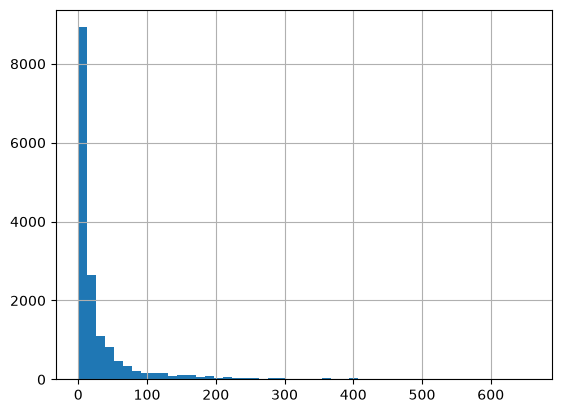

In [29]:
import pandas as pd

gap_df = pd.read_sql_query("""
    SELECT r.invoice, r.customer_id, r.stockcode,
           julianday(r.invoicedate) - julianday(s.invoicedate) AS days_gap
    FROM transactions r
    JOIN transactions s
        ON s.customer_id = r.customer_id
        AND s.stockcode = r.stockcode
        AND s.quantity > 0
        AND NOT s.is_non_product AND NOT s.is_guest
        AND s.invoicedate < r.invoicedate
    WHERE r.is_return AND NOT r.is_non_product AND NOT r.is_guest
""", conn)

# dedupe: keep only the closest prior sale per return line
gap_df = gap_df.sort_values("days_gap").drop_duplicates(subset=["invoice", "customer_id", "stockcode"])

print(gap_df["days_gap"].describe(percentiles=[.25,.5,.75,.9,.95,.99]))
gap_df["days_gap"].hist(bins=50)

Leakage Pourcentage

In [12]:
# all production that are noot returned and not write-off and not non-product
gross_query = """
SELECT SUM(revenue) AS gross_revenue
FROM transactions
WHERE NOT is_return AND NOT is_writeoff AND NOT is_non_product
"""
gross = pd.read_sql_query(gross_query, conn)

returned_query = """
    SELECT SUM(revenue) AS returned_revenue
    FROM transactions
    WHERE is_return AND NOT is_non_product
    """
returned = pd.read_sql_query(returned_query, conn)

revenue_lost = abs(returned["returned_revenue"].iloc[0])
gross_revenue = gross["gross_revenue"].iloc[0]

leakage_percentage = (revenue_lost / gross_revenue) * 100

print(f"Gross Revenue: {gross_revenue:,.2f}")
print(f"Revenue Lost: {revenue_lost:,.2f}")
print(f"Revenue Leakage: {leakage_percentage:.2f}%")

Gross Revenue: 20,047,603.31
Revenue Lost: 721,576.74
Revenue Leakage: 3.60%


Leakage by country

In [13]:
returned_country_query = """
SELECT country, SUM(revenue) AS returned_revenue
FROM transactions
WHERE is_return AND NOT is_non_product
GROUP BY country
ORDER BY returned_revenue
"""
returned_by_country = pd.read_sql_query(returned_country_query, conn)
returned_by_country.head(10)

,country,returned_revenue
0,United Kingdom,-636910.11
1,EIRE,-20360.55
2,France,-17689.19
3,Spain,-12955.19
4,Germany,-8928.84
5,Denmark,-4067.10
6,Netherlands,-3677.98
7,Japan,-3277.14
8,Channel Islands,-2188.52
9,USA,-2080.32


Top returned products

In [14]:
returned_products_query = """
SELECT
    t.stockcode,
    p.description,
    SUM(-t.revenue) AS returned_value,
    COUNT(*) AS return_count
FROM transactions t
JOIN products p ON t.stockcode = p.stockcode
WHERE t.is_return AND NOT t.is_non_product
GROUP BY t.stockcode, p.description
ORDER BY returned_value DESC
LIMIT 20
"""
returned_products = pd.read_sql_query(returned_products_query, conn)
returned_products.head(10)

,stockcode,description,returned_value,return_count
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,77479.64,10
2,22423,REGENCY CAKESTAND 3 TIER,16749.60,359
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,9389.65,137
4,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,7173.87,74
5,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6614.37,4
6,79323W,WHITE CHERRY LIGHTS,6421.10,128
7,21843,RED RETROSPOT CAKE STAND,5401.60,163
8,84078A,SET/4 WHITE RETRO STORAGE CUBES,5187.65,22
9,23113,PANTRY CHOPPING BOARD,4803.06,7


In [16]:
returned_products_query = """
SELECT
    t.stockcode,
    p.description,
    SUM(-t.revenue) AS returned_value,
    COUNT(*) AS return_count
FROM transactions t
JOIN products p ON t.stockcode = p.stockcode
WHERE t.is_return AND NOT t.is_non_product
GROUP BY t.stockcode, p.description
ORDER BY return_count DESC
LIMIT 20
"""
returned_products = pd.read_sql_query(returned_products_query, conn)
returned_products.head(10)

,stockcode,description,returned_value,return_count
0,22423,REGENCY CAKESTAND 3 TIER,16749.60,359
1,22138,BAKING SET 9 PIECE RETROSPOT,4072.75,213
2,21232,STRAWBERRY CERAMIC TRINKET BOX,1105.23,190
3,21843,RED RETROSPOT CAKE STAND,5401.60,163
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,9389.65,137
5,79323W,WHITE CHERRY LIGHTS,6421.10,128
6,21527,RED RETROSPOT TRADITIONAL TEAPOT,1423.88,122
7,22197,SMALL POPCORN HOLDER,620.57,96
8,22960,JAM MAKING SET WITH JARS,1051.04,91
9,82483,WOOD 2 DRAWER CABINET WHITE FINISH,1704.65,91


Leakage by mouth

In [17]:
leakage_by_month_query = """
SELECT
    strftime('%Y-%m', invoicedate) AS month,

    SUM(CASE 
        WHEN is_return THEN -revenue 
        ELSE 0 
    END) AS returned_value,

    SUM(CASE 
        WHEN revenue > 0 THEN revenue 
        ELSE 0 
    END) AS gross_revenue,

    ROUND(
        100.0 * SUM(CASE 
            WHEN is_return THEN -revenue 
            ELSE 0 
        END)
        / NULLIF(
            SUM(CASE 
                WHEN revenue > 0 THEN revenue 
                ELSE 0 
            END), 0
        ),
        2
    ) AS leakage_pct

FROM transactions

WHERE is_non_product = 0

GROUP BY month

ORDER BY leakage_pct DESC
"""

leakage_by_month = pd.read_sql_query(leakage_by_month_query, conn)

leakage_by_month.head(12)

,month,returned_value,gross_revenue,leakage_pct
0,2011-12,174126.76,614979.75,28.31
1,2011-01,91526.30,670829.68,13.64
2,2011-04,33305.01,515584.65,6.46
3,2010-05,35159.04,644952.02,5.45
4,2011-10,43992.16,1103711.66,3.99
5,2010-06,25264.76,698020.03,3.62
6,2010-09,27777.97,869777.43,3.19
7,2011-08,22923.57,724141.15,3.17
8,2010-07,17026.98,633068.13,2.69
9,2009-12,19508.33,789010.10,2.47


Distiguish true returns and standalone negative quantity

In [22]:
true_returns_query = """
WITH matched_returns AS (
    SELECT 
        r.invoice,
        r.customer_id,
        r.stockcode,
        r.invoicedate AS return_date,
        r.quantity AS return_quantity,

        s.invoicedate AS original_purchase_date,
        s.quantity AS original_purchase_quantity,

        ROW_NUMBER() OVER (
            PARTITION BY r.invoice, r.customer_id, r.stockcode
            ORDER BY s.invoicedate DESC
        ) AS rn

    FROM transactions r

    JOIN transactions s
        ON s.customer_id = r.customer_id
        AND s.stockcode = r.stockcode
        AND s.quantity > 0
        AND NOT s.is_non_product
        AND NOT s.is_guest
        AND s.invoicedate < r.invoicedate
        AND s.invoicedate >= date(r.invoicedate, '-1 month')

    WHERE r.is_return
      AND NOT r.is_non_product
      AND NOT r.is_guest
)

SELECT
    invoice,
    customer_id,
    stockcode,
    return_date,
    return_quantity,
    original_purchase_date,
    original_purchase_quantity
FROM matched_returns
WHERE rn = 1
"""

conn.execute("""
CREATE INDEX IF NOT EXISTS idx_txn_return_match
ON transactions(customer_id, stockcode, invoicedate, quantity)
""")

true_returns = pd.read_sql_query(true_returns_query, conn)

In [25]:
return_classification_query = """

SELECT 
    r.invoice,
    r.customer_id,
    r.stockcode,
    r.invoicedate AS return_date,
    r.quantity AS return_quantity,

    CASE
        WHEN EXISTS (
            SELECT 1
            FROM transactions s
            WHERE s.customer_id = r.customer_id
              AND s.stockcode = r.stockcode
              AND s.quantity > 0
              AND NOT s.is_non_product
              AND NOT s.is_guest
              AND s.invoicedate < r.invoicedate
              AND s.invoicedate >= date(r.invoicedate, '-1 month')
        )
        THEN 'True Return'
        ELSE 'Standalone'
    END AS return_type

FROM transactions r

WHERE r.is_return
  AND NOT r.is_non_product
  AND NOT r.is_guest

"""

return_classification = pd.read_sql_query(
    return_classification_query,
    conn
)

In [30]:
return_classification["return_type"].value_counts()

return_type
True Return    12340
Standalone      5484
Name: count, dtype: int64

- **Q2 — RFM Segmentation**

In [ ]:
"""
select
"""

In [32]:
customers.head(10)

,customer_id,country,first_seen,last_seen
0,12346,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:17:00
1,12347,Iceland,2010-10-31 14:20:00,2011-12-07 15:52:00
2,12348,Finland,2010-09-27 14:59:00,2011-09-25 13:13:00
3,12349,Italy,2009-12-04 12:49:00,2011-11-21 09:51:00
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00
5,12351,Unspecified,2010-11-29 15:23:00,2010-11-29 15:23:00
6,12352,Norway,2010-11-12 10:20:00,2011-11-03 14:37:00
7,12353,Bahrain,2010-10-27 12:44:00,2011-05-19 17:47:00
8,12354,Spain,2011-04-21 13:11:00,2011-04-21 13:11:00
9,12355,Bahrain,2010-05-21 11:59:00,2011-05-09 13:49:00


In [41]:
# Reference date = last date in the dataset
reference_date = pd.read_sql_query(
    "SELECT MAX(invoicedate) AS max_date FROM transactions",
    conn
)["max_date"].iloc[0]

reference_date = pd.to_datetime(reference_date)

# RFM calculation per customer
rfm_query = """
SELECT 
    c.customer_id,
    MAX(t.invoicedate) AS last_purchase,
    COUNT(DISTINCT t.invoice) AS frequency,
    SUM(t.revenue) AS monetary

FROM customers AS c

JOIN transactions AS t
    ON c.customer_id = t.customer_id

WHERE NOT t.is_return
  AND NOT t.is_non_product

GROUP BY c.customer_id
"""

rfm = pd.read_sql_query(rfm_query, conn)

In [42]:
# Convert dates
rfm["last_purchase"] = pd.to_datetime(rfm["last_purchase"])

# Calculate Recency in days
rfm["recency"] = (
    reference_date - rfm["last_purchase"]
).dt.days

# Final RFM table
rfm = rfm[
    ["customer_id", "recency", "frequency", "monetary"]
]

rfm.head(10)

,customer_id,recency,frequency,monetary
0,12346,325,3,77347.01
1,12347,1,8,5633.32
2,12348,74,5,1658.40
3,12349,18,3,3678.69
4,12350,309,1,294.40
5,12351,374,1,300.93
6,12352,35,9,1729.54
7,12353,203,2,406.76
8,12354,231,1,1079.40
9,12355,213,2,947.61


In [ ]:
rfm[["recency", "frequency", "monetary"]].describe()
#describe gives us information about the central tendency, dispersion, and shape of the distribution of the RFM metrics. It provides insights into the average values, variability, and potential outliers in the data, 
# which can inform marketing strategies and customer segmentation efforts.

,recency,frequency,monetary
count,5853.000000,5853.000000,5853.000000
mean,199.166240,6.252520,2968.795927
std,208.505959,12.750248,14534.902992
min,0.000000,1.000000,0.000000
25%,24.000000,1.000000,344.140000
50%,94.000000,3.000000,880.040000
75%,378.000000,7.000000,2282.280000
max,738.000000,373.000000,603421.650000


In [ ]:
rfm[["recency", "frequency", "monetary"]].skew()
#skew is done to understand the asymmetry of the distribution of the RFM metrics. A positive skew indicates that the tail on the right side is longer or fatter than the left side, while a negative skew indicates that the tail on the left side is longer or fatter than the right side. 
#This information can help identify potential outliers.

recency       0.894549
frequency    12.040385
monetary     25.550227
dtype: float64

In [ ]:
rfm[["recency", "frequency", "monetary"]].quantile(
    [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]
)
# the quantile function is to understand the distribution of the clients based on their recency, frequency, and monetary values. 
# It helps identify the spread of the data and potential outliers, which can inform marketing strategies and customer segmentation efforts.

,recency,frequency,monetary
0.00,0.0,1.0,0.000
0.10,8.0,1.0,162.540
0.25,24.0,1.0,344.140
0.50,94.0,3.0,880.040
0.75,378.0,7.0,2282.280
0.90,530.0,13.0,5490.068
1.00,738.0,373.0,603421.650


In [46]:
for n in [3, 4, 5]:
    print(f"\n--- {n} buckets ---")
    
    for col in ["recency", "frequency", "monetary"]:
        buckets = pd.qcut(rfm[col], q=n, duplicates="drop")
        print(f"\n{col}:")
        print(buckets.value_counts().sort_index())


--- 3 buckets ---

recency:
recency
(-0.001, 40.0]      1969
(40.0, 262.333]     1933
(262.333, 738.0]    1951
Name: count, dtype: int64

frequency:
frequency
(0.999, 2.0]    2564
(2.0, 5.0]      1503
(5.0, 373.0]    1786
Name: count, dtype: int64

monetary:
monetary
(-0.001, 468.017]        1951
(468.017, 1602.123]      1951
(1602.123, 603421.65]    1951
Name: count, dtype: int64

--- 4 buckets ---

recency:
recency
(-0.001, 24.0]    1465
(24.0, 94.0]      1466
(94.0, 378.0]     1469
(378.0, 738.0]    1453
Name: count, dtype: int64

frequency:
frequency
(0.999, 3.0]    3223
(3.0, 7.0]      1340
(7.0, 373.0]    1290
Name: count, dtype: int64

monetary:
monetary
(-0.001, 344.14]        1464
(344.14, 880.04]        1463
(880.04, 2282.28]       1463
(2282.28, 603421.65]    1463
Name: count, dtype: int64

--- 5 buckets ---

recency:
recency
(-0.001, 18.0]    1188
(18.0, 58.0]      1174
(58.0, 186.0]     1155
(186.0, 408.0]    1173
(408.0, 738.0]    1163
Name: count, dtype: int64

frequenc

In [ ]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)
# Recency (R): 1 = least recent, 4 = most recent

In [ ]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"],
    q=3,
    labels=[1, 2, 3],
    duplicates="drop"
).astype(int)
# Frequency (F): 1 = lowest frequency, 3 = highest frequency

In [ ]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)
# Monetary (M): 1 = lowest spending, 4 = highest spending

In [50]:
rfm[[
    "customer_id",
    "recency",
    "frequency",
    "monetary",
    "R_score",
    "F_score",
    "M_score"
]].head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,12346,325,3,77347.01,2,2,4
1,12347,1,8,5633.32,4,3,4
2,12348,74,5,1658.40,3,2,3
3,12349,18,3,3678.69,4,2,4
4,12350,309,1,294.40,2,1,1
5,12351,374,1,300.93,2,1,1
6,12352,35,9,1729.54,3,3,3
7,12353,203,2,406.76,2,1,2
8,12354,231,1,1079.40,2,1,3
9,12355,213,2,947.61,2,1,3


In [51]:
def assign_segment(row):
    if row["R_score"] >= 3 and row["F_score"] == 3 and row["M_score"] >= 3:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 2:
        return "Loyal / Potential Loyalists"
    elif row["R_score"] <= 2 and row["F_score"] >= 2:
        return "At Risk"
    else:
        return "Low Value / Lost"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

In [52]:
q2_output = (
    rfm.groupby("segment")
       .agg(
           customers=("customer_id", "count"),
           avg_recency=("recency", "mean"),
           avg_frequency=("frequency", "mean"),
           avg_monetary=("monetary", "mean")
       )
       .round(2)
       .reset_index()
)

q2_output

,segment,customers,avg_recency,avg_frequency,avg_monetary
0,At Risk,1081,282.46,5.88,2304.28
1,Champions,1398,25.64,16.83,8897.32
2,Low Value / Lost,2564,310.50,1.37,537.56
3,Loyal / Potential Loyalists,810,35.07,3.96,1319.35


- **Q3 — Churn Definition (statistically derived)**

In [74]:
query = """
SELECT DISTINCT
    customer_id,
    invoice,
    invoicedate
FROM transactions
WHERE NOT is_return
  AND NOT is_non_product
  AND NOT is_guest
ORDER BY customer_id, invoicedate
"""

purchases = pd.read_sql_query(query, conn)

purchases.head()

,customer_id,invoice,invoicedate
0,12346,499763,2010-03-02 13:08:00
1,12346,513774,2010-06-28 13:53:00
2,12346,541431,2011-01-18 10:01:00
3,12347,529924,2010-10-31 14:20:00
4,12347,537626,2010-12-07 14:57:00


In [78]:
purchases["invoicedate"] = pd.to_datetime(purchases["invoicedate"])

purchases["previous_purchase"] = (
    purchases.groupby("customer_id")["invoicedate"].shift(1)
)

purchases["gap_days"] = (
    purchases["invoicedate"] - purchases["previous_purchase"]
).dt.total_seconds() / 86400

In [79]:
gaps = purchases.dropna(subset=["previous_purchase"])

gaps["gap_days"].describe()

count    30807.000000
mean        52.011141
std         75.861617
min          0.000000
25%          7.010417
50%         24.972917
75%         62.020139
max        714.152083
Name: gap_days, dtype: float64

In [82]:
gaps["gap_days"].quantile([0.75,0.85 ,0.90, 0.95])

0.75     62.020139
0.85    100.027986
0.90    135.862222
0.95    207.006181
Name: gap_days, dtype: float64

In [83]:
last_purchase = (
    purchases
    .groupby("customer_id")["invoicedate"]
    .max()
    .reset_index()
)

last_purchase.head()

,customer_id,invoicedate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00


In [84]:
reference_date = purchases["invoicedate"].max()

reference_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
last_purchase["days_since_last_purchase"] = (
    reference_date - last_purchase["invoicedate"]
).dt.total_seconds() / 86400

last_purchase.head()
#purchase compared to the reference date gives us the number of days since the last purchase for each customer. 
# This metric can be used to identify customers who have not made a purchase in a long time and may be at risk of churning.

,customer_id,invoicedate,days_since_last_purchase
0,12346,2011-01-18 10:01:00,325.117361
1,12347,2011-12-07 15:52:00,1.873611
2,12348,2011-09-25 13:13:00,74.984028
3,12349,2011-11-21 09:51:00,18.124306
4,12350,2011-02-02 16:01:00,309.867361


In [ ]:
churn_cutoff = 136

churned_count = (
    last_purchase["days_since_last_purchase"] > churn_cutoff
).sum()

churned_count

In [94]:
# 0.85    100.027986
# 0.90    135.862222
# 0.95    207.006181
#sensivity test of the churn cutoff value to see how many customers would be classified as churned at different thresholds. This can help in understanding the impact of different cutoff values on the number of churned customers and inform decision-making regarding customer retention strategies.

cutoffs = [106, 136, 166]

for cutoff in cutoffs:
    count = (
        last_purchase["days_since_last_purchase"] > cutoff
    ).sum()
    
    print(f"Cutoff = {cutoff} days → {count} churned customers")

Cutoff = 106 days → 2847 churned customers
Cutoff = 136 days → 2635 churned customers
Cutoff = 166 days → 2464 churned customers


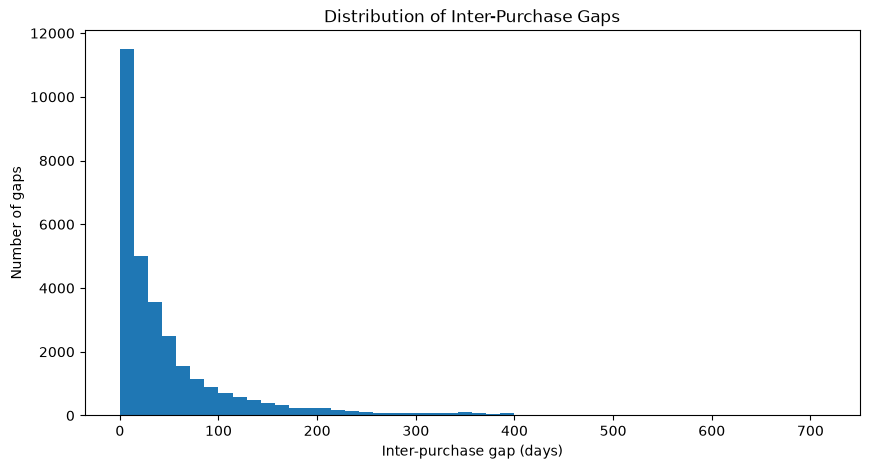

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(gaps["gap_days"], bins=50)
plt.xlabel("Inter-purchase gap (days)")
plt.ylabel("Number of gaps")
plt.title("Distribution of Inter-Purchase Gaps")
plt.show()

- **Q4 — Cohort Retention**

In [ ]:
first_purchase = (
    purchases
    .groupby("customer_id")["invoicedate"]
    .min()
    .reset_index()
)

first_purchase["cohort_month"] = first_purchase["invoicedate"].dt.to_period("M")


In [101]:
purchases["purchase_month"] = (
    purchases["invoicedate"].dt.to_period("M")
)
purchases = purchases.merge(
    first_purchase[["customer_id", "cohort_month"]],
    on="customer_id",
    how="left"
)

In [103]:
purchases["month_n"] = (
    purchases["purchase_month"] - purchases["cohort_month"]
).apply(lambda x: x.n)
purchases.head(10)

,customer_id,invoice,invoicedate,previous_purchase,gap_days,purchase_month,cohort_month,month_n
0,12346,499763,2010-03-02 13:08:00,NaT,NaN,2010-03,2010-03,0
1,12346,513774,2010-06-28 13:53:00,2010-03-02 13:08:00,118.031250,2010-06,2010-03,3
2,12346,541431,2011-01-18 10:01:00,2010-06-28 13:53:00,203.838889,2011-01,2010-03,10
3,12347,529924,2010-10-31 14:20:00,NaT,NaN,2010-10,2010-10,0
4,12347,537626,2010-12-07 14:57:00,2010-10-31 14:20:00,37.025694,2010-12,2010-10,2
5,12347,542237,2011-01-26 14:30:00,2010-12-07 14:57:00,49.981250,2011-01,2010-10,3
6,12347,549222,2011-04-07 10:43:00,2011-01-26 14:30:00,70.842361,2011-04,2010-10,6
7,12347,556201,2011-06-09 13:01:00,2011-04-07 10:43:00,63.095833,2011-06,2010-10,8
8,12347,562032,2011-08-02 08:48:00,2011-06-09 13:01:00,53.824306,2011-08,2010-10,10
9,12347,573511,2011-10-31 12:25:00,2011-08-02 08:48:00,90.150694,2011-10,2010-10,12


In [109]:
cohort_activity = (
    purchases
    .groupby(["cohort_month", "month_n"])["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

cohort_activity.head()

,cohort_month,month_n,active_customers
0,2009-12,0,951
1,2009-12,1,333
2,2009-12,2,317
3,2009-12,3,404
4,2009-12,4,360


In [113]:
cohort_activity["cohort_size"] = (
    cohort_activity
    .groupby("cohort_month")["active_customers"]
    .transform("first")
)

cohort_activity["retention_rate"] = (
    cohort_activity["active_customers"]
    / cohort_activity["cohort_size"]
)

retention_table = (
    cohort_activity
    .pivot(
        index="cohort_month",
        columns="month_n",
        values="retention_rate"
    )
)
retention_table = retention_table * 100

retention_table.head(10)

month_n,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.015773,33.333333,42.481598,37.854890,35.962145,37.644585,34.384858,33.753943,36.172450,...,30.283912,26.288118,30.283912,28.391167,25.867508,25.446898,31.335436,30.389064,40.588854,19.663512
2010-01,100.0,21.467391,32.065217,31.521739,27.173913,30.978261,26.902174,23.369565,28.532609,32.608696,...,15.217391,24.456522,20.380435,19.293478,20.108696,25.271739,19.836957,25.271739,5.706522,NaN
2010-02,100.0,23.466667,22.666667,29.333333,24.533333,19.733333,19.200000,28.800000,25.600000,27.733333,...,20.000000,16.000000,16.266667,14.400000,22.933333,22.933333,16.533333,5.866667,NaN,NaN
2010-03,100.0,19.047619,23.129252,24.263039,23.129252,20.408163,24.716553,30.612245,27.664399,10.884354,...,17.006803,17.460317,15.646259,17.687075,20.408163,21.315193,7.709751,NaN,NaN,NaN
2010-04,100.0,19.047619,19.047619,15.986395,18.367347,22.108844,27.551020,26.530612,10.544218,10.884354,...,15.646259,13.945578,14.965986,18.027211,22.789116,5.782313,NaN,NaN,NaN,NaN
2010-05,100.0,15.686275,16.862745,17.647059,17.647059,25.490196,21.176471,12.549020,5.882353,8.235294,...,12.549020,13.725490,16.470588,15.294118,4.705882,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.602996,18.726592,20.599251,23.220974,28.464419,12.734082,8.988764,8.239700,11.235955,...,12.359551,13.108614,20.224719,4.868914,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.675676,18.378378,29.729730,29.189189,14.054054,11.351351,14.594595,14.594595,11.351351,...,17.297297,23.783784,8.108108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,19.631902,28.834356,32.515337,16.564417,11.656442,9.815951,12.883436,13.496933,12.883436,...,19.631902,7.361963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- **Q5 — Customer Lifetime Value**

In [115]:
query = """
SELECT
    customer_id,
    SUM(revenue) AS clv
FROM transactions
WHERE NOT is_return
  AND NOT is_non_product
  AND NOT is_guest
GROUP BY customer_id
ORDER BY clv DESC
"""

clv = pd.read_sql_query(query, conn)

clv.head(10)

,customer_id,clv
0,18102,603421.65
1,14646,526751.52
2,14156,301354.73
3,14911,275539.51
4,17450,246973.09
5,13694,196055.01
6,17511,175603.55
7,16446,168472.50
8,12415,144033.37
9,16684,141487.77
